In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [34]:
df = pd.read_csv('height-weight.csv')

In [35]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [36]:
# scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')


Text(38.097222222222214, 0.5, 'Height')

In [37]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


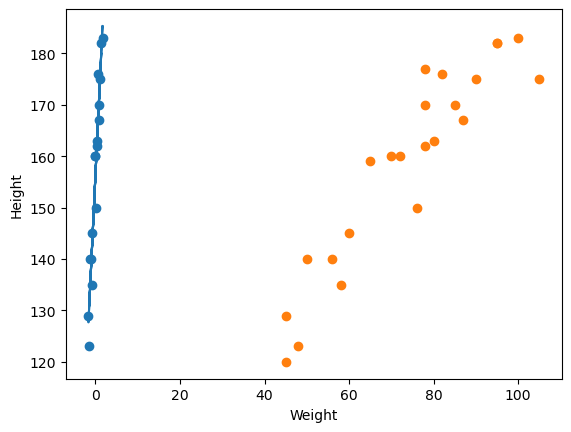

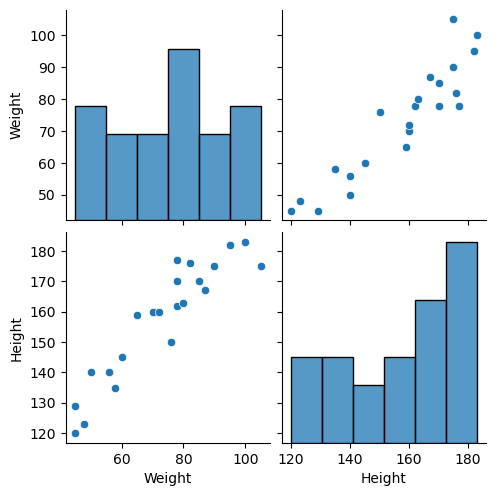

In [38]:
# Seaborn for visulization
import seaborn as sns
sns.pairplot(df)
plt.show()

In [39]:
# Independent and dependent feature
x=df[['Weight']]  ###independent feature should be data frame or 2 dimensional array
y = df[['Height']]  # this variable can be in series or 1d array

In [40]:
X_series = df['Weight']
np.array(X_series).shape

(23,)

In [41]:
np.array(y).shape

(23, 1)

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [44]:
# standardization
from sklearn.preprocessing import StandardScaler

In [45]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)

In [46]:
X_test= scaler.transform(X_test)

In [47]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [48]:
#  apply simple linear regresion
from sklearn.linear_model import LinearRegression

In [49]:
regression = LinearRegression(n_jobs=1)

In [50]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=1)

In [51]:
print('Coefficient or slop:', regression.coef_)
print('Intercept:' , regression.intercept_)

Coefficient or slop: [[17.2982057]]
Intercept: [156.47058824]


In [52]:
# plot training data plot best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train,regression.predict(X_train))

prediction of test data
1. predicted height output = intercept + coef_(weights)
2. y_pred_test = 156.470 + 17.29(X_test)

In [ ]:
y_pred = regression.predict(X_test)

In [61]:
# Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [65]:


mse=mean_squared_error(y_test,y_pred)
# mse=mean_squared_error(y_test,X_test)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [66]:
from sklearn.metrics import r2_score

In [67]:
score = r2_score(y_test, y_pred)
print(score)

0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [68]:
# display adjusted R-squared
1- (1- score)*(len(y_test)/(len(y_test)-X_test.shape[1]-1))

0.6041240076971914

In [76]:
!pip install statsmodels

In [78]:
# # OLS Linear Regression
# import statemodels.api as sm

## OLS Linear Regression
import statsmodels.api as sm

In [79]:
model = sm.OLS(y_train,X_train).fit()

In [80]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [81]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Mon, 10 Aug 2026   Prob (F-statistic):                       0.664
Time:                        23:58:39   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\infinix\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [82]:
# prediction for new data
regression.predict(scaler.transform([[71]]))

c:\Users\infinix\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[154.92952202]])